# Frozen Prithvi + WCE Warm-up → Direct DMI + Smooth Logit Morphology — Xuân Thủy

**Bản đồ mục tiêu: 21/09/2026.** Đây là một run mới, giữ nguyên sáu ảnh DN, sáu band, split, patch, batch schedule, offset −1000 và chuẩn hóa của notebook WCE.

Run này **không nạp checkpoint WCE cũ**. Nó bắt đầu từ Prithvi-EO-2.0-300M-TL pretrained gốc, đóng băng encoder, dùng WCE để khởi động neck/UNet/head, rồi chỉ chuyển sang exact DMI + morphology khi gate ổn định đạt hai lần liên tiếp. Mọi artifact nằm trong run folder P5 riêng; output WCE và direct-DMI P4 cũ không bị ghi đè.


### Thiết kế đã khóa

```text
Warm-up (312–936 step)
6 ảnh × 6 band → frozen Prithvi encoder (eval, no grad)
→ trainable learned neck + UNet decoder + 11-class head
→ raw logits → WCE
Morphology: frozen và bypass

Sau gate
frozen Prithvi encoder → task side + trainable smooth closing 3×3
→ Softmax → exact DMI, batch hiệu dụng 16
```

Readiness được kiểm tra mỗi 156 step: validation DMI đủ rank/hữu hạn; exact-DMI backward hữu hạn trên bốn batch train cố định; validation dự đoán đủ 11 lớp; recall lớp 5/6/7 đều ≥ 0,05. Chọn **checkpoint sớm nhất** đạt hai lần liên tiếp, không chọn theo WCE F1.

Giai đoạn DMI lưu hai model độc lập: macro-F1 validation là chính; validation DMI loss đủ rank là phụ. Encoder vẫn frozen trong nhánh P5 đầu tiên này; partial fine-tuning sẽ là thí nghiệm khác.


## 1. Kết nối Google Drive


In [1]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Cài thư viện và helper theo commit cố định


In [2]:
import subprocess,sys
from pathlib import Path

WORK=Path('/content/prithvi_xtseg_staged_workspace')
WORK.mkdir(parents=True,exist_ok=True)
requirements=['terratorch==1.2.12','torchgeo==0.9.0','timm==1.0.30',
              'huggingface-hub==1.33.0','rasterio==1.5.2','pandas==2.2.3',
              'numpy==2.3.5','einops==0.8.2','matplotlib>=3.8,<4',
              'PyYAML>=6,<7','geopandas>=1,<2','tqdm>=4.66,<5']
subprocess.run([sys.executable,'-m','pip','install','-q',*requirements],check=True)

BASELINE_COMMIT='0775770ae87b83b7d2982ed727226128685f3fba'
BASELINE=WORK/'public_baseline'
if not BASELINE.exists():
    subprocess.run(['git','clone','https://github.com/hongphuc-maker/xuan-thuy-dmi-segmentation.git',str(BASELINE)],check=True)
subprocess.run(['git','-C',str(BASELINE),'checkout','--detach',BASELINE_COMMIT],check=True)
head=subprocess.check_output(['git','-C',str(BASELINE),'rev-parse','HEAD'],text=True).strip()
assert head==BASELINE_COMMIT
subprocess.run([sys.executable,'-m','pip','install','-q','--no-deps','-e',str(BASELINE)],check=True)
sys.path.insert(0,str(BASELINE/'src'))
print('Helper commit:',head)


Helper commit: 0775770ae87b83b7d2982ed727226128685f3fba


## 3. Nạp payload staged experiment đã khóa SHA256


In [3]:
import base64,hashlib,io,zipfile

PAYLOAD_B64='...'
PAYLOAD_SHA256='b2a19ceed5ea2a43a30dce054cc1d64b538e6207525d74f63ebc2a72fdde035a'
payload=base64.b64decode(PAYLOAD_B64)
assert hashlib.sha256(payload).hexdigest()==PAYLOAD_SHA256,'Payload checksum khác'
with zipfile.ZipFile(io.BytesIO(payload)) as archive:
    for entry in archive.infolist():
        destination=(WORK/entry.filename).resolve()
        if WORK.resolve() not in destination.parents:
            raise ValueError('Unsafe archive path')
    archive.extractall(WORK)

loaded=sys.modules.get('prithvi_xtseg')
if loaded is not None:
    loaded_path=Path(getattr(loaded,'__file__','')).resolve()
    if WORK.resolve() not in loaded_path.parents:
        for name in list(sys.modules):
            if name=='prithvi_xtseg' or name.startswith('prithvi_xtseg.'):
                del sys.modules[name]
sys.path.insert(0,str(WORK))
import torch,terratorch,importlib.metadata
print({p:importlib.metadata.version(p) for p in ['torch','torchvision','terratorch','torchgeo','timm','segmentation-models-pytorch','numpy']})
print('GPU:',torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU — cần GPU để train')
print('Payload:',PAYLOAD_SHA256)


{'torch': '2.11.0+cu130', 'torchvision': '0.26.0+cu130', 'terratorch': '1.2.12', 'torchgeo': '0.9.0', 'timm': '1.0.30', 'segmentation-models-pytorch': '0.5.0', 'numpy': '2.3.5'}
GPU: Tesla T4
Payload: b2a19ceed5ea2a43a30dce054cc1d64b538e6207525d74f63ebc2a72fdde035a


## 4. Cấu hình run P5 riêng


In [4]:
import json,re

RUN_SUFFIX=''
DATA_ROOT=Path('/content/drive/MyDrive/Prithvi_Colab/data')
RUNS_ROOT=Path('/content/drive/MyDrive/Prithvi_Colab/runs')
DN_OFFSET=-1000.0
OFFSET_CONFIRMED=False
CLOUD_MASKS={}

assert re.fullmatch(r'[A-Za-z0-9_-]*',RUN_SUFFIX)
config=json.loads((WORK/'experiment_staged_warmup_dmi_morphology.json').read_text(encoding='utf-8'))
config['experiment_id']+=RUN_SUFFIX
config['radiometry']['dn_offset']=DN_OFFSET
config['radiometry']['confirmed_from_export_code']=OFFSET_CONFIRMED
config['cloud_masks']=CLOUD_MASKS
assert config['initialization']['WCE_checkpoint'] is None
assert config['warmup']['minimum_steps']==312
assert config['warmup']['maximum_steps']==936
assert config['warmup']['readiness_interval_steps']==156
assert config['warmup']['consecutive_ready_evaluations']==2
assert config['training']['encoder_policy']=='frozen'
assert config['objective']=={
    'name':'exact_dmi','matrix_jitter':0.0,
    'effective_batch_implementation':'two-pass microbatch recomputation with RNG replay'}
CONFIG_PATH=WORK/'effective_experiment.json'
CONFIG_PATH.write_text(json.dumps(config,ensure_ascii=False,indent=2),encoding='utf-8')
RUN_ROOT=RUNS_ROOT/config['experiment_id']
print('Run mới:',RUN_ROOT)
print('Ngày:',config['active_dates'],'→ mục tiêu',config['target_date'])
print('Warm-up:',config['warmup'])
print('Final selection:',config['selection'])


Run mới: /content/drive/MyDrive/Prithvi_Colab/runs/P5_multitemporal6_sep21_UNet_FrozenPrithvi_WCEWarmup_DMI_Morphology
Ngày: ['2026-01-09', '2026-05-26', '2026-07-18', '2026-08-12', '2026-09-03', '2026-09-21'] → mục tiêu 2026-09-21
Warm-up: {'objective': 'weighted_cross_entropy', 'encoder_policy': 'frozen_eval', 'trainable_modules': 'all non-encoder task modules except morphology', 'morphology_policy': 'frozen_and_bypassed', 'minimum_steps': 312, 'maximum_steps': 936, 'readiness_interval_steps': 156, 'consecutive_ready_evaluations': 2, 'readiness': {'fixed_train_batches': 4, 'DMI_rank': 11, 'finite_DMI_loss': True, 'finite_exact_DMI_backward': True, 'validation_predicted_classes': 11, 'minimum_recall_by_code': {'5': 0.05, '6': 0.05, '7': 0.05}}, 'selection': 'earliest checkpoint satisfying two consecutive readiness evaluations'}
Final selection: {'primary': 'validation_macro_F1_11_after_train_permutation', 'secondary': 'validation_DMI_loss_full_rank', 'permutation_source': 'fixed train

## 5. Audit dữ liệu và fixed train-only panel


/content/prithvi_xtseg_staged_workspace/prithvi_xtseg/data.py:158: UserWarning: No cloud/SCL masks: nodata validity is not cloud validity; exploratory experiment.
  warnings.warn("No cloud/SCL masks: nodata validity is not cloud validity; exploratory experiment.")
/content/prithvi_xtseg_staged_workspace/prithvi_xtseg/data.py:160: UserWarning: Radiometric offset is an explicit assumption; verify export code before scientific reporting.
  warnings.warn("Radiometric offset is an explicit assumption; verify export code before scientific reporting.")


,date,file,valid_pixels,sha256,cloud_mask_available
0,2026-01-09,Sentinel2_2026-01-09_S2B_MSIL2A_20260109T_HSTD...,1471398,50bc6049e2ceae1cd92f15d880c9d94d8c7727b4cb97c3...,False
1,2026-05-26,Sentinel2_2026-05-26_S2A_MSIL2A_20260526T_HSTD...,1471306,9d4f4af0393b411759668173452cc5df658d895b5ccfbf...,False
2,2026-07-18,Sentinel2_2026-07-18_S2B_MSIL2A_20260718T_HSTD...,1471392,6fa20e2ec4f9dc73999d8b2e3ffd35ea670f4b7109507c...,False
3,2026-08-12,Sentinel2_2026-08-12_S2C_MSIL2A_20260812T_HSTD...,1471400,21a57a5432f684165b15fa8a6f52f8e7b103a9dc03a6a2...,False
4,2026-09-03,Sentinel2_2026-09-03_S2A_MSIL2A_20260903T_HSTD...,1471393,df112425707fe4fcc301d295c07c307f416ee1cbbd196d...,False
5,2026-09-21,Sentinel2_2026-09-21_S2C_MSIL2A_20260921T_HSTD...,1471243,d924eb0e19175ba0c38d1fc058516783778bf39fb4b272...,False


,code,class,train_pixels
0,1,Anm,87083
1,2,Bgt,190976
2,3,Dc,94719
3,4,Dnn,183098
4,5,DK,1015
5,6,trống,1495
6,7,Gt,4666
7,8,Rnm,84044
8,9,Stx,48474
9,10,Vbn,326520


{'shape': [1374, 1821], 'common_labeled_pixels': 1471132, 'train_pixels': 1071386, 'validation_pixels': 294156, 'n_patches': 4992, 'n_batches': 312, 'n_validation_windows': 36, 'shared_input_pixels': 0}
Fixed train panel: {'n_batches': 4, 'n_patches': 64, 'used_for': 'channel-to-class permutation and warm-up DMI readiness only; never final accuracy'}


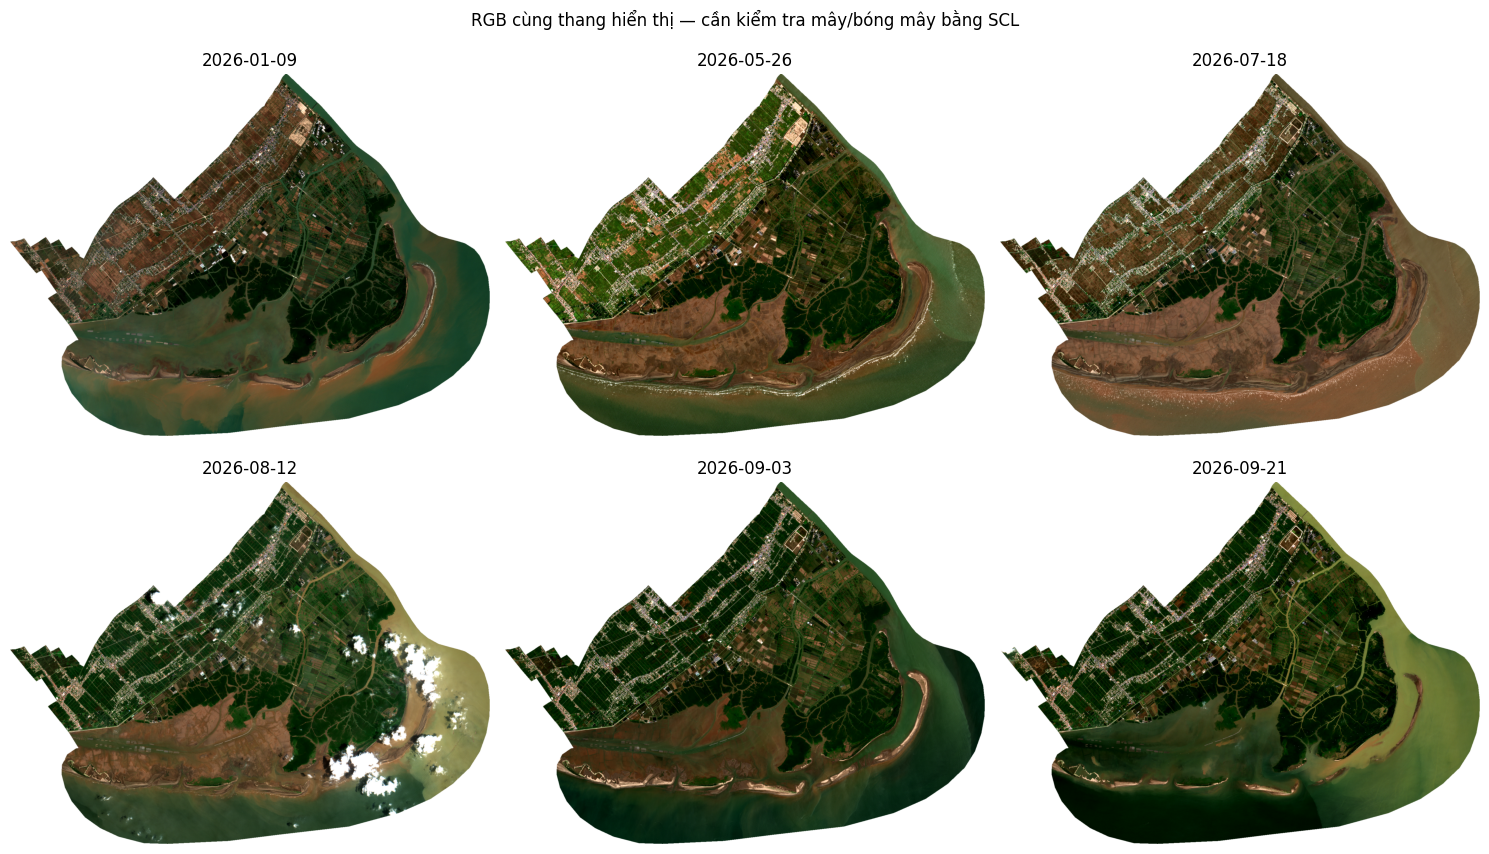

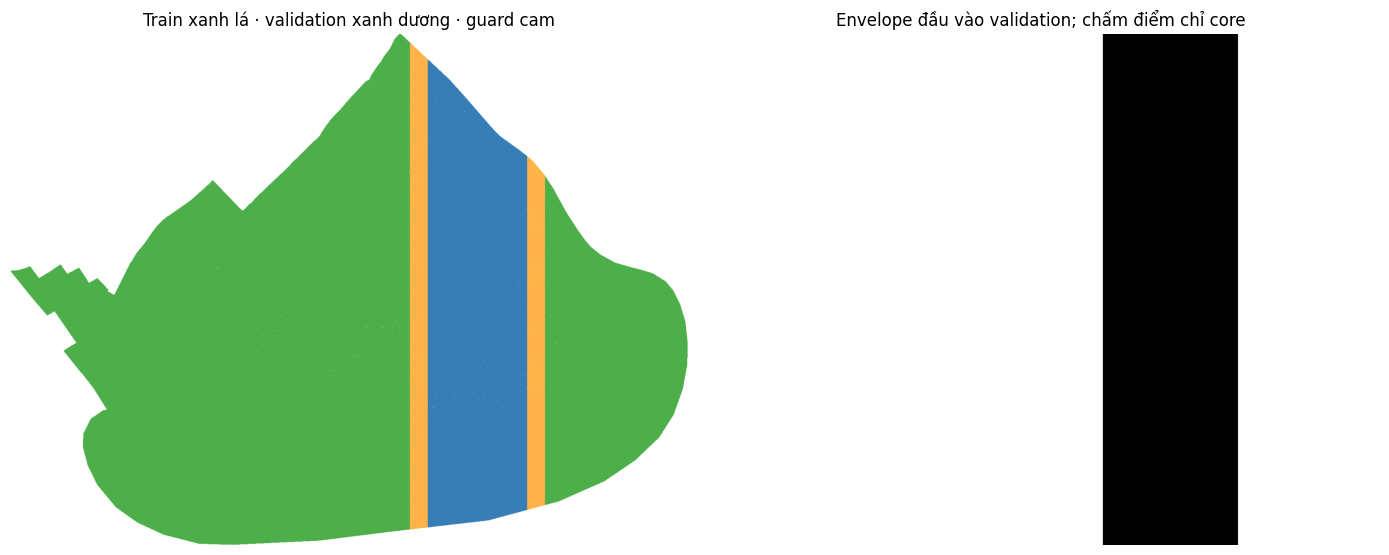

In [5]:
from IPython.display import display
import pandas as pd
import matplotlib.pyplot as plt
from prithvi_xtseg.training import open_experiment
from prithvi_xtseg.reporting import (show_inputs,show_split,show_history,
                                     show_warmup_history,show_map,show_selected_checkpoints)

experiment=open_experiment(CONFIG_PATH,DATA_ROOT,RUN_ROOT)
audit=json.loads((RUN_ROOT/'prepared'/'DATA_AUDIT.json').read_text())
panel=json.loads((RUN_ROOT/'FIXED_TRAIN_PANEL.json').read_text())
display(pd.DataFrame(audit['images']))
display(pd.DataFrame({'code':range(1,12),
                      'class':[config['class_map'][str(i)] for i in range(1,12)],
                      'train_pixels':audit['train_class_counts']}))
print({k:audit[k] for k in ['shape','common_labeled_pixels','train_pixels','validation_pixels',
                            'n_patches','n_batches','n_validation_windows','shared_input_pixels']})
print('Fixed train panel:',{k:panel[k] for k in ['n_batches','n_patches','used_for']})
assert audit['n_batches']==312
assert audit['shared_input_pixels']==0
fig=show_inputs(experiment);plt.show();plt.close(fig)
fig=show_split(experiment);plt.show();plt.close(fig)


## 6. Frozen-encoder WCE warm-up và readiness gate

Cell này bắt đầu từ Prithvi pretrained gốc khi run P5 chưa có resume. Nó tự resume `warmup_latest_resume.pt`, kiểm tra mỗi 156 step và dừng ở checkpoint sớm nhất đạt hai lần liên tiếp. Nếu tới step 936 vẫn không đạt, notebook dừng và ghi `WARMUP_BLOCKED.json`; không tự chuyển sang DMI.


In [11]:
if not torch.cuda.is_available():
    raise RuntimeError('Chọn Runtime → Change runtime type → GPU rồi chạy lại')
warmup_result=experiment.warmup()
display(warmup_result)
display(experiment.parameter_report())
fig=show_warmup_history(RUN_ROOT);plt.show();plt.close(fig)
if (RUN_ROOT/'warmup_readiness_history.json').exists():
    readiness=json.loads((RUN_ROOT/'warmup_readiness_history.json').read_text())
    display(pd.DataFrame([{'step':x['warmup_step'],'ready':x['ready'],
                           'consecutive':x['consecutive_ready'],**x['flags'],**x['rare_recalls']}
                          for x in readiness]))
if not warmup_result['transition_ready']:
    raise RuntimeError('Warm-up chưa đạt gate; xem WARMUP_BLOCKED.json/readiness history. Không chạy DMI.')
assert (RUN_ROOT/'warmup_transition.pt').exists()


{'stage': 'WCE_warmup',
 'step': 936,
 'target_step': 936,
 'completed': True,
 'transition_ready': True,
 'transition_via_gate_override': True,
 'consecutive_numerical_ready': 6,
 'original_consecutive_semantic_ready': 0,
 'method_hash': '551d2d6e5061ce1c459ce6675e0d167fdf636c3e237fac944eddd369ab505236',
 'selection_rule': {'name': 'numerical_safety_gate_v1',
  'required_flags': ['validation_DMI_rank_11',
   'validation_DMI_finite',
   'four_fixed_batches_rank_11',
   'four_fixed_batches_finite_DMI',
   'four_fixed_batches_finite_backward'],
  'diagnostic_only_flags': ['validation_predicts_all_11_classes',
   'rare_recall_gate']}}

ValueError: Load the model first

## 7. Smoke test exact DMI sau warm-up


In [12]:
smoke=experiment.smoke_test()
display(smoke)
assert smoke['effective_batch_size']==16
assert smoke['DMI']['rank']==11 and smoke['DMI']['finite_loss']
assert smoke['gradients']['finite']
assert smoke['parameter_report']['encoder_trainable']==0
assert smoke['parameter_report']['morphology_trainable']==99


{'effective_batch_size': 16,
 'two_pass_exact_DMI': True,
 'DMI': {'n_samples': 685918,
  'classes_present': 11,
  'sign': 1.0,
  'loss': 40.48252826241681,
  'min_singular_value': 0.0008517066467694462,
  'max_singular_value': 0.28799451887855865,
  'condition_number': 338.13816056377175,
  'rank': 11,
  'finite_loss': True},
 'gradients': {'finite': True,
  'gradient_tensors': 35,
  'missing_gradient_tensors': 0,
  'nonfinite_gradient_names': []},
 'device': 'cuda',
 'peak_cuda_gb': 2.89293568,
 'warmup_transition_step': 936,
 'warmup_transition_sha256': '49ebccc7c3b2424b39caa4efd511468ba3fa4a92fc31fce1f70b5b1533e2adda',
 'parameter_report': {'encoder_parameters': 303886338,
  'task_parameters': 20318923,
  'morphology_parameters': 99,
  'encoder_trainable': 0,
  'task_trainable': 20318923,
  'morphology_trainable': 99,
  'encoder_training_mode': False},
 'method_hash': '551d2d6e5061ce1c459ce6675e0d167fdf636c3e237fac944eddd369ab505236'}

## 8. Pilot direct DMI đến step 78

Đây là step nội bộ của giai đoạn DMI, tách biệt với warm-up step. Chạy lại không vượt quá 78. Pilot tạo thử cả hai checkpoint validation; chưa phải kết quả final.


Post-warm-up direct-DMI steps:   0%|          | 0/78 [00:00<?, ?it/s]

DMI step 78: mapped val F1=0.4105, IoU=0.3198, DMI=65.1787, rank=11, gate=False


{'stage': 'direct_DMI',
 'dmi_step': 78,
 'target_step': 78,
 'completed': False,
 'early_stopped': False,
 'best_macro_F1': 0.4105255872056964,
 'best_validation_DMI': 65.17874389056531,
 'method_hash': '551d2d6e5061ce1c459ce6675e0d167fdf636c3e237fac944eddd369ab505236'}

,role,file,dmi_step,macro_F1_11,macro_IoU_11,OA,validation_DMI_loss,validation_DMI_rank,validation_DMI_condition_number,acceptance_passed
0,primary_macro_F1,best_validation_macro_f1.pt,78,0.410526,0.319818,0.781541,65.178744,11,382523.47108,False
1,secondary_DMI_loss,best_validation_dmi_loss.pt,78,0.410526,0.319818,0.781541,65.178744,11,382523.47108,False


AttributeError: 'DataFrame' object has no attribute 'step'

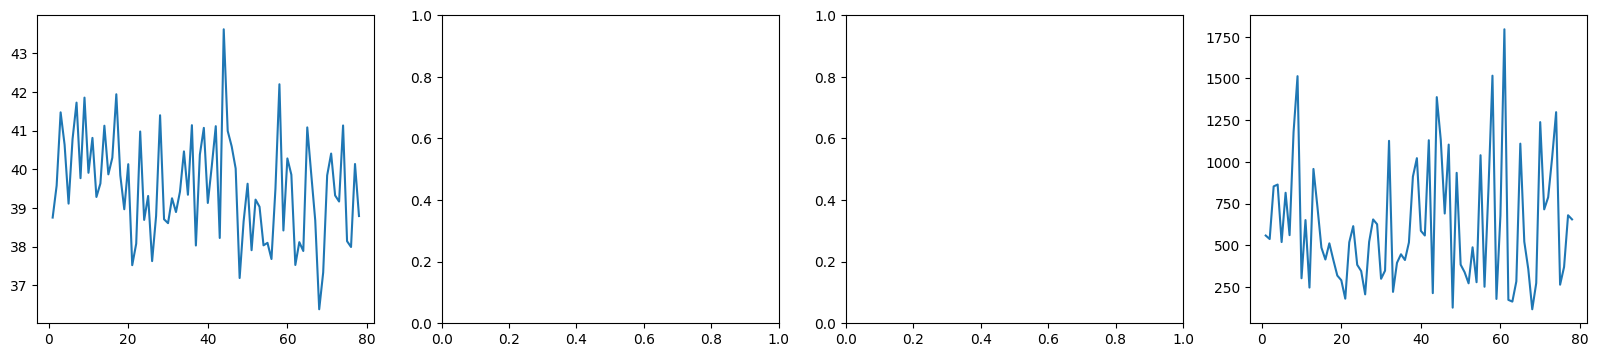

In [13]:
PILOT_DMI_TARGET_STEP=78
pilot_result=experiment.train(target_step=PILOT_DMI_TARGET_STEP)
display(pilot_result)
display(show_selected_checkpoints(experiment))
fig=show_history(RUN_ROOT);plt.show();plt.close(fig)
if (RUN_ROOT/'dmi_latest_class_permutation.json').exists():
    display(json.loads((RUN_ROOT/'dmi_latest_class_permutation.json').read_text()))
if (RUN_ROOT/'dmi_latest_validation_per_class.csv').exists():
    display(pd.read_csv(RUN_ROOT/'dmi_latest_validation_per_class.csv'))


/usr/local/lib/python3.13/dist-packages/matplotlib/_fontconfig_pattern.py:85: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  parse = parser.parseString(pattern)
/usr/local/lib/python3.13/dist-packages/matplotlib/_fontconfig_pattern.py:89: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  parser.resetCache()
/usr/local/lib/python3.13/dist-packages/matplotlib/_mathtext.py:2010: PyparsingDeprecationWarning: 'oneOf' deprecated - use 'one_of'
  p.space          = oneOf(self._space_widths)("space")
/usr/local/lib/python3.13/dist-packages/matplotlib/_mathtext.py:2020: PyparsingDeprecationWarning: 'leaveWhitespace' deprecated - use 'leave_whitespace'
  )("sym").leaveWhitespace()
/usr/local/lib/python3.13/dist-packages/matplotlib/_mathtext.py:1984: PyparsingDeprecationWarning: 'setName' deprecated - use 'set_name'
  val.setName(key)
/usr/local/lib/python3.13/dist-packages/matplotlib/_mathtext.py:1987: PyparsingDeprecationWarning: 'setParseA

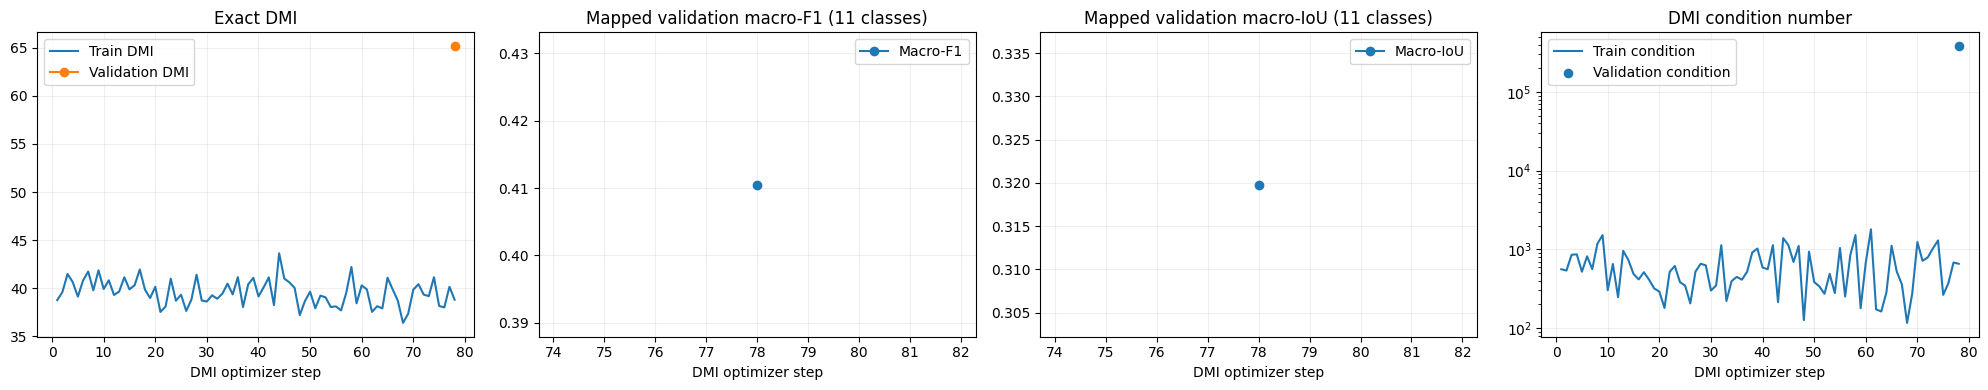

,OA,macro_F1_11,macro_IoU_11,predicted_classes,n_pixels,validation_DMI_loss,validation_DMI_sign,validation_DMI_rank,validation_DMI_min_singular_value,validation_DMI_max_singular_value,validation_DMI_condition_number,validation_DMI_finite,permutation_train_macro_recall,acceptance_passed,validation_DMI_checkpoint_eligible,dmi_step
0,0.781541,0.410526,0.319818,10,294156,65.178744,1.0,11,7.286439e-07,0.278723,382523.47108,True,0.949425,False,True,78


,code,class,support,predicted,precision,recall,F1,IoU
0,1,Anm,119658,104962,0.935348,0.820472,0.874152,0.776439
1,2,Bgt,9260,16948,0.386653,0.707667,0.500076,0.333401
2,3,Dc,899,601,0.527454,0.352614,0.422667,0.267963
3,4,Dnn,782,3815,0.193447,0.943734,0.321079,0.191241
4,5,DK,1662,0,0.000000,0.000000,0.000000,0.000000
5,6,trống,652,73,0.000000,0.000000,0.000000,0.000000
6,7,Gt,510,517,0.201161,0.203922,0.202532,0.112676
7,8,Rnm,66690,74483,0.827894,0.924636,0.873595,0.775560
8,9,Stx,31491,26475,0.434788,0.365533,0.397164,0.247788
9,10,Vbn,60073,54252,0.931560,0.841293,0.884129,0.792321


{'true_class_to_output_channel': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
 'output_channel_to_true_class': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
 'output_channel_to_class_code': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
 'train_panel_macro_recall': 0.9494245319570822,
 'train_panel_support': [79767,
  169646,
  93995,
  181424,
  682,
  1459,
  4578,
  47591,
  39899,
  252200,
  47665],
 'train_panel_confusion_raw_channels': [[73683,
   37,
   42,
   15,
   0,
   0,
   2877,
   188,
   2925,
   0,
   0],
  [64, 165376, 0, 0, 0, 0, 73, 1289, 117, 331, 2396],
  [202, 0, 81299, 1643, 152, 0, 1386, 0, 9313, 0, 0],
  [655, 0, 4856, 152704, 138, 0, 4290, 0, 18781, 0, 0],
  [0, 0, 0, 0, 682, 0, 0, 0, 0, 0, 0],
  [0, 0, 0, 0, 0, 1449, 0, 10, 0, 0, 0],
  [21, 0, 4, 0, 47, 0, 4496, 0, 10, 0, 0],
  [122, 83, 0, 0, 0, 399, 0, 45946, 1026, 12, 3],
  [727, 1, 705, 397, 83, 0, 778, 543, 36636, 0, 29],
  [0, 2496, 0, 0, 0, 40, 0, 179, 0, 249039, 446],
  [0, 36, 0, 0, 0, 287, 0, 14, 35, 3, 47290]],
 'assignment_m

,role,file,dmi_step,macro_F1_11,macro_IoU_11,OA,validation_DMI_loss,validation_DMI_rank,validation_DMI_condition_number,acceptance_passed
0,primary_macro_F1,best_validation_macro_f1.pt,78,0.410526,0.319818,0.781541,65.178744,11,382523.47108,False
1,secondary_DMI_loss,best_validation_dmi_loss.pt,78,0.410526,0.319818,0.781541,65.178744,11,382523.47108,False


In [14]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt


def show_history(run_root):
    run_root = Path(run_root)

    training_path = run_root / "dmi_training_history.csv"
    validation_path = run_root / "dmi_validation_history.csv"

    fig, axes = plt.subplots(1, 4, figsize=(20, 4))

    # -----------------------------
    # Training history
    # -----------------------------
    if training_path.exists():
        try:
            training = pd.read_csv(training_path)
        except pd.errors.EmptyDataError:
            training = pd.DataFrame()

        if not training.empty:
            axes[0].plot(
                training["step"],
                training["train_DMI_loss"],
                label="Train DMI",
            )

            axes[3].plot(
                training["step"],
                training["train_DMI_condition_number"],
                label="Train condition",
            )

    # -----------------------------
    # Validation history
    # -----------------------------
    if validation_path.exists():
        try:
            validation = pd.read_csv(validation_path)
        except pd.errors.EmptyDataError:
            validation = pd.DataFrame()

        if not validation.empty:
            # Validation CSV dùng dmi_step thay vì step
            validation_step_column = (
                "dmi_step"
                if "dmi_step" in validation.columns
                else "step"
            )

            validation_steps = validation[validation_step_column]

            axes[0].plot(
                validation_steps,
                validation["validation_DMI_loss"],
                marker="o",
                label="Validation DMI",
            )

            axes[1].plot(
                validation_steps,
                validation["macro_F1_11"],
                marker="o",
                label="Macro-F1",
            )

            axes[2].plot(
                validation_steps,
                validation["macro_IoU_11"],
                marker="o",
                label="Macro-IoU",
            )

            axes[3].scatter(
                validation_steps,
                validation["validation_DMI_condition_number"],
                label="Validation condition",
                s=35,
            )

    titles = [
        "Exact DMI",
        "Mapped validation macro-F1 (11 classes)",
        "Mapped validation macro-IoU (11 classes)",
        "DMI condition number",
    ]

    for axis, title in zip(axes, titles):
        axis.set_title(title)
        axis.set_xlabel("DMI optimizer step")
        axis.grid(alpha=0.2)

    for axis in (axes[0], axes[1], axes[2], axes[3]):
        if axis.lines or axis.collections:
            axis.legend()

    axes[3].set_yscale("log")
    fig.tight_layout()

    return fig


# Vẽ lại mà không chạy training
fig = show_history(RUN_ROOT)
plt.show()
plt.close(fig)

# Hiển thị các artifact mà cell cũ chưa chạy tới
validation_history = pd.read_csv(
    RUN_ROOT / "dmi_validation_history.csv"
)
display(validation_history)

if (RUN_ROOT / "dmi_latest_validation_per_class.csv").exists():
    display(
        pd.read_csv(
            RUN_ROOT / "dmi_latest_validation_per_class.csv"
        )
    )

if (RUN_ROOT / "dmi_latest_class_permutation.json").exists():
    display(
        json.loads(
            (
                RUN_ROOT
                / "dmi_latest_class_permutation.json"
            ).read_text()
        )
    )

display(show_selected_checkpoints(experiment))

## 9. Full DMI training — chỉ bật sau khi duyệt pilot


Post-warm-up direct-DMI steps:   0%|          | 0/3042 [00:00<?, ?it/s]

DMI step 156: mapped val F1=0.4034, IoU=0.3146, DMI=66.3474, rank=11, gate=False
DMI step 312: mapped val F1=0.4136, IoU=0.3261, DMI=64.8372, rank=11, gate=False
DMI step 468: mapped val F1=0.4220, IoU=0.3365, DMI=65.9861, rank=11, gate=False
DMI step 624: mapped val F1=0.4150, IoU=0.3282, DMI=64.7010, rank=11, gate=False
DMI step 780: mapped val F1=0.4275, IoU=0.3392, DMI=65.0026, rank=11, gate=False
DMI step 936: mapped val F1=0.4237, IoU=0.3303, DMI=61.7289, rank=11, gate=False
DMI step 1092: mapped val F1=0.4152, IoU=0.3265, DMI=64.7417, rank=11, gate=False
DMI step 1248: mapped val F1=0.4025, IoU=0.3145, DMI=62.6377, rank=11, gate=False
DMI step 1404: mapped val F1=0.4217, IoU=0.3338, DMI=66.1534, rank=11, gate=False
DMI step 1560: mapped val F1=0.4242, IoU=0.3346, DMI=66.0458, rank=11, gate=False
DMI step 1716: mapped val F1=0.4077, IoU=0.3202, DMI=63.4798, rank=11, gate=False


{'stage': 'direct_DMI',
 'dmi_step': 1716,
 'target_step': 3120,
 'completed': True,
 'early_stopped': True,
 'best_macro_F1': 0.4275153594073417,
 'best_validation_DMI': 61.72894850589919,
 'method_hash': '551d2d6e5061ce1c459ce6675e0d167fdf636c3e237fac944eddd369ab505236',
 'model_selection': {'primary_role': 'primary_macro_F1',
  'mapping_source': 'fixed train-only permutation panel',
  'warmup_transition_sha256': '49ebccc7c3b2424b39caa4efd511468ba3fa4a92fc31fce1f70b5b1533e2adda',
  'checkpoints': {'primary_macro_F1': {'available': True,
    'file': 'best_validation_macro_f1.pt',
    'sha256': '169b8d407bd61d11ce41c4ae660dc5304e12f8cf972ecd1db49d0f00e5e42001',
    'dmi_step': 780,
    'summary': {'OA': 0.8167876908851086,
     'macro_F1_11': 0.4275153594073417,
     'macro_IoU_11': 0.33923228245809295,
     'predicted_classes': 9,
     'n_pixels': 294156,
     'validation_DMI_loss': 65.00256798538875,
     'validation_DMI_sign': -1.0,
     'validation_DMI_rank': 11,
     'validation_D

,role,file,dmi_step,macro_F1_11,macro_IoU_11,OA,validation_DMI_loss,validation_DMI_rank,validation_DMI_condition_number,acceptance_passed
0,primary_macro_F1,best_validation_macro_f1.pt,780,0.427515,0.339232,0.816788,65.002568,11,188423.583964,False
1,secondary_DMI_loss,best_validation_dmi_loss.pt,936,0.423663,0.330257,0.792019,61.728949,11,207761.210385,False


/usr/local/lib/python3.13/dist-packages/matplotlib/_mathtext.py:2170: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  result = self._expression.parseString(s)
/usr/local/lib/python3.13/dist-packages/pyparsing/util.py:466: PyparsingDeprecationWarning: 'parseAll' argument is deprecated, use 'parse_all'
  return fn(self, *args, **kwargs)
/usr/local/lib/python3.13/dist-packages/matplotlib/_mathtext.py:2178: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  ParserElement.resetCache()


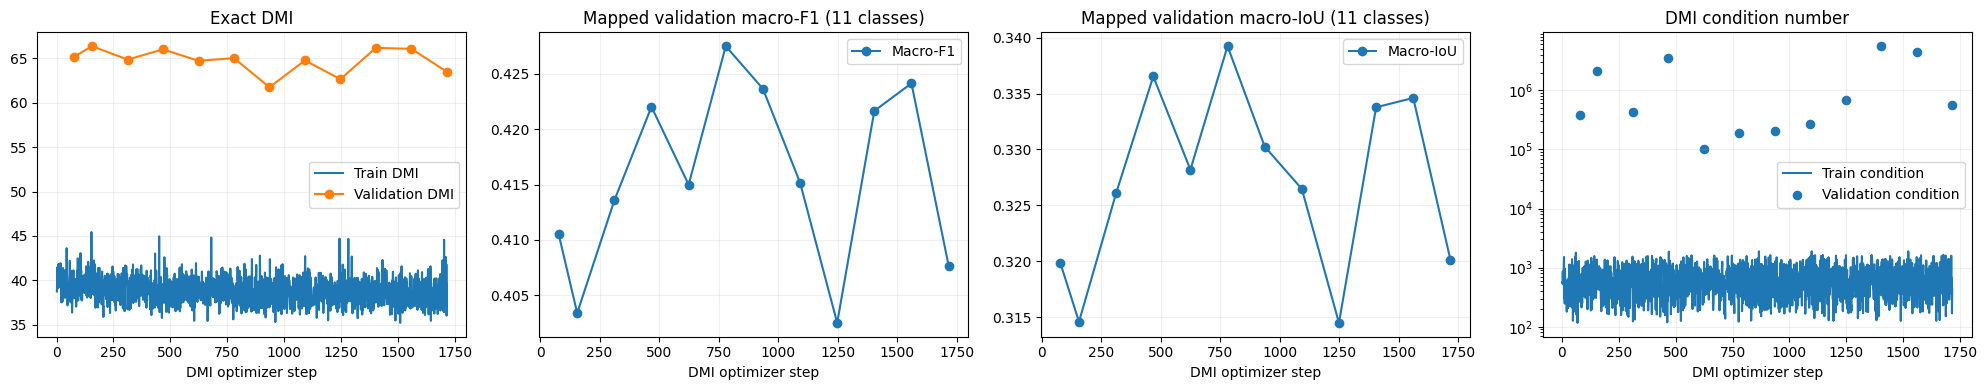

In [16]:
RUN_FULL_DMI_TRAINING=True
if RUN_FULL_DMI_TRAINING:
    training_result=experiment.train()
    display(training_result)
    display(show_selected_checkpoints(experiment))
    fig=show_history(RUN_ROOT)
    fig.savefig(RUN_ROOT/'dmi_training_curves.png',dpi=160,bbox_inches='tight')
    plt.show();plt.close(fig)
else:
    print('Đang dừng ở DMI pilot. Chỉ đổi RUN_FULL_DMI_TRAINING=True sau khi duyệt diagnostics.')


## 10. Hai checkpoint cuối và model selection


In [17]:
display(show_selected_checkpoints(experiment))
selection_path=RUN_ROOT/'MODEL_SELECTION.json'
if selection_path.exists():
    display(json.loads(selection_path.read_text()))
else:
    print('MODEL_SELECTION.json chỉ được niêm phong khi DMI training hoàn tất.')


,role,file,dmi_step,macro_F1_11,macro_IoU_11,OA,validation_DMI_loss,validation_DMI_rank,validation_DMI_condition_number,acceptance_passed
0,primary_macro_F1,best_validation_macro_f1.pt,780,0.427515,0.339232,0.816788,65.002568,11,188423.583964,False
1,secondary_DMI_loss,best_validation_dmi_loss.pt,936,0.423663,0.330257,0.792019,61.728949,11,207761.210385,False


{'primary_role': 'primary_macro_F1',
 'mapping_source': 'fixed train-only permutation panel',
 'warmup_transition_sha256': '49ebccc7c3b2424b39caa4efd511468ba3fa4a92fc31fce1f70b5b1533e2adda',
 'checkpoints': {'primary_macro_F1': {'available': True,
   'file': 'best_validation_macro_f1.pt',
   'sha256': '169b8d407bd61d11ce41c4ae660dc5304e12f8cf972ecd1db49d0f00e5e42001',
   'dmi_step': 780,
   'summary': {'OA': 0.8167876908851086,
    'macro_F1_11': 0.4275153594073417,
    'macro_IoU_11': 0.33923228245809295,
    'predicted_classes': 9,
    'n_pixels': 294156,
    'validation_DMI_loss': 65.00256798538875,
    'validation_DMI_sign': -1.0,
    'validation_DMI_rank': 11,
    'validation_DMI_min_singular_value': 1.8206278430584587e-06,
    'validation_DMI_max_singular_value': 0.343049223253273,
    'validation_DMI_condition_number': 188423.58396375354,
    'validation_DMI_finite': True,
    'permutation_train_macro_recall': 0.9656991487808366,
    'acceptance_passed': False,
    'validation_D

## 11. Xuất bản đồ từ checkpoint macro-F1


Acceptance gate failed: output is exploratory, not an accepted model.


Probability mosaic:   0%|          | 0/165 [00:00<?, ?it/s]

{'method_hash': '551d2d6e5061ce1c459ce6675e0d167fdf636c3e237fac944eddd369ab505236',
 'checkpoint_file': 'best_validation_macro_f1.pt',
 'checkpoint_sha256': '169b8d407bd61d11ce41c4ae660dc5304e12f8cf972ecd1db49d0f00e5e42001',
 'checkpoint_summary': {'OA': 0.7815410870422497,
  'macro_F1_11': 0.4105255872056964,
  'macro_IoU_11': 0.31981816626471427,
  'predicted_classes': 10,
  'n_pixels': 294156,
  'validation_DMI_loss': 65.17874389056531,
  'validation_DMI_sign': 1.0,
  'validation_DMI_rank': 11,
  'validation_DMI_min_singular_value': 7.286439277783298e-07,
  'validation_DMI_max_singular_value': 0.27872340443507865,
  'validation_DMI_condition_number': 382523.4710799274,
  'validation_DMI_finite': True,
  'permutation_train_macro_recall': 0.9494245319570822,
  'acceptance_passed': False,
  'validation_DMI_checkpoint_eligible': True,
  'dmi_step': 78},
 'permutation': {'true_class_to_output_channel': [0,
   1,
   2,
   3,
   4,
   5,
   6,
   7,
   8,
   9,
   10],
  'output_channel_to

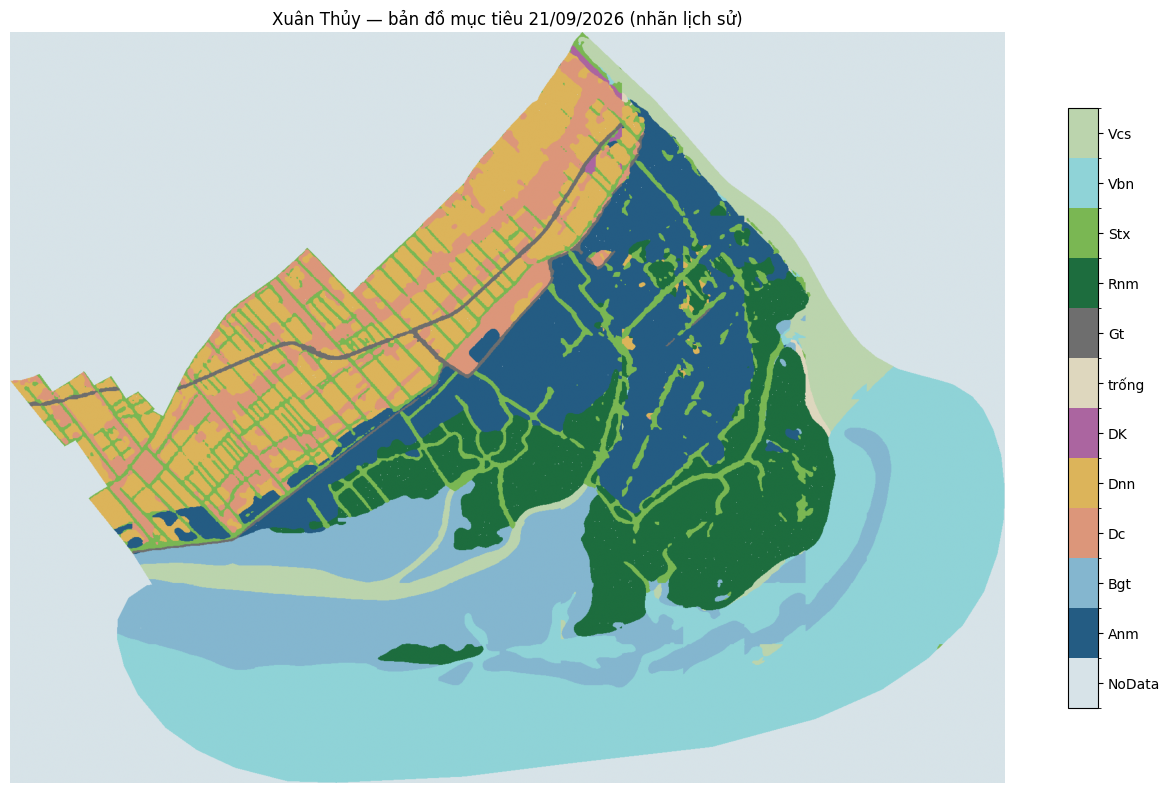

GeoTIFF: /content/drive/MyDrive/Prithvi_Colab/runs/P5_multitemporal6_sep21_UNet_FrozenPrithvi_WCEWarmup_DMI_Morphology/map/classes_sep21_2026.tif


In [19]:
EXPORT_FINAL_MAP=True
if EXPORT_FINAL_MAP:
    map_result=experiment.map()
    display(map_result)
    fig=show_map(experiment)
    fig.savefig(RUN_ROOT/'map_preview.png',dpi=180,bbox_inches='tight')
    plt.show();plt.close(fig)
    print('GeoTIFF:',RUN_ROOT/'map'/'classes_sep21_2026.tif')
else:
    print('Giữ EXPORT_FINAL_MAP=False cho đến khi DMI_TRAINING_COMPLETE.json tồn tại.')


## 12. Tùy chọn: đối chiếu điểm cũ sau khi chốt bản đồ


In [21]:
EVALUATE_OLD_POINTS=True
POINTS_ROOT=Path('/content/drive/MyDrive/Prithvi_Colab/data')
if EVALUATE_OLD_POINTS:
    from prithvi_xtseg.inference import evaluate_reference_points
    agreement=evaluate_reference_points(experiment.scene,RUN_ROOT,POINTS_ROOT,confirm=True)
    display(agreement)
    display(pd.read_csv(RUN_ROOT/'reference_point_agreement'/'per_class.csv'))
else:
    print('Bỏ qua đối chiếu điểm cũ.')


{'OA': 0.9247104247104247,
 'macro_F1_11': 0.5856086483567526,
 'macro_IoU_11': 0.5499895126609514,
 'predicted_classes': 9,
 'n_pixels': 1036,
 'macro_F1_represented_classes': 0.9202421617034684,
 'input_points': 1037,
 'excluded_points': 1,
 'interpretation': 'Agreement with previously used reference points; September accuracy not established',
 'map_sha256': 'c8e8c35c9952c8ac8e669b39e054b4db01a682116f35943f388c85377e3aec10',
 'method_hash': '551d2d6e5061ce1c459ce6675e0d167fdf636c3e237fac944eddd369ab505236',
 'artifacts': {'points.csv': '307a2353b9b05391bf100e290857e754a0b849068ddbe4f53d77a38892660fe0',
  'per_class.csv': '784b28356a182157d1f5769573d314c33c4f0e6da38d0b8420381913d460ce5b',
  'confusion.csv': '80ddc529287097140992170281ae45a7940e924f385336623a91a07ff8e64a04'}}

,code,class,support,predicted,precision,recall,F1,IoU
0,1,Anm,161,159,0.987421,0.975155,0.981250,0.963190
1,2,Bgt,134,138,0.971014,1.000000,0.985294,0.971014
2,3,Dc,0,18,0.000000,0.000000,0.000000,0.000000
3,4,Dnn,240,238,0.949580,0.941667,0.945607,0.896825
4,5,DK,0,0,0.000000,0.000000,0.000000,0.000000
5,6,trống,0,0,0.000000,0.000000,0.000000,0.000000
6,7,Gt,0,12,0.000000,0.000000,0.000000,0.000000
7,8,Rnm,198,197,0.984772,0.979798,0.982278,0.965174
8,9,Stx,100,79,0.810127,0.640000,0.715084,0.556522
9,10,Vbn,103,111,0.927928,1.000000,0.962617,0.927928


## Giới hạn diễn giải

- WCE warm-up chỉ là bước hiệu chỉnh task-side ngắn; checkpoint này không phải model cuối.
- Direct DMI vẫn sử dụng nhãn lịch sử; không gọi đây là học không giám sát hay khẳng định không phụ thuộc nhãn.
- Permutation chỉ sửa ánh xạ channel một-một; không sửa mất lớp, nhập lớp hoặc lỗi không gian.
- Validation dùng nhãn lịch sử chưa rõ ngày, nên metric không phải accuracy độc lập của bản đồ tháng 9.
- Smooth logit closing có thể giảm phân mảnh nhưng không bảo đảm tăng accuracy.
- Ảnh chưa có SCL/cloud mask; ảnh 12/08 có dấu hiệu mây.
- Output notebook mới chỉ là cấu hình/code. Chỉ coi số liệu trong run P5 là kết quả mới sau khi các cell thực sự chạy trên Colab.
